# Intro + Exec Summary

Howdy howdy. This analysis applies five regression methods to predict residential sale prices using the 
Ames Housing dataset (1,460 observations, 79 features (263 features once encoded)).
Key finding: Ridge regression achieved the most consistent results across all seed splits. 

# Packages + Data load

In [1]:
import kagglehub
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import inv_boxcox
import math
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression

c:\Users\RobertMorsch\Practice_Projects\Ames-House-Prices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
import os

# 1. Load variables from .env into the environment
load_dotenv() 

# 2. Access them using the standard OS library
kaggle_user = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

# Download the latest version of the competition data
path = kagglehub.competition_download("house-prices-advanced-regression-techniques")

print("Path to competition files:", path)

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))

Path to competition files: C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\data_description.txt
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\sample_submission.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\test.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\train.csv


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.head()

Number of rows: 1460
Number of columns: 81
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns
print("Categorical Variables:")
print(len(cat_cols))
print(cat_cols.values)
print("\n")
print("Numerical Variables:")
print(len(num_cols))
print(num_cols.values)

Categorical Variables:
43
<StringArray>
[     'MSZoning',        'Street',         'Alley',      'LotShape',
   'LandContour',     'Utilities',     'LotConfig',     'LandSlope',
  'Neighborhood',    'Condition1',    'Condition2',      'BldgType',
    'HouseStyle',     'RoofStyle',      'RoofMatl',   'Exterior1st',
   'Exterior2nd',    'MasVnrType',     'ExterQual',     'ExterCond',
    'Foundation',      'BsmtQual',      'BsmtCond',  'BsmtExposure',
  'BsmtFinType1',  'BsmtFinType2',       'Heating',     'HeatingQC',
    'CentralAir',    'Electrical',   'KitchenQual',    'Functional',
   'FireplaceQu',    'GarageType',  'GarageFinish',    'GarageQual',
    'GarageCond',    'PavedDrive',        'PoolQC',         'Fence',
   'MiscFeature',      'SaleType', 'SaleCondition']
Length: 43, dtype: str


Numerical Variables:
35
<StringArray>
[           'Id',    'MSSubClass',       'LotArea',   'OverallQual',
   'OverallCond',     'YearBuilt',  'YearRemodAdd',    'BsmtFinSF1',
    'BsmtFinSF2',

C:\Users\RobertMorsch\AppData\Local\Temp\ipykernel_39560\584291390.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=['object']).columns


# Null Handling

Seeing what columns have NAs then handling them. What was interesting is that many of these NAs were NOT actually NAs in the excel sheet. 
They were "None" or "NA" which pd.read_csv by default reads as nulls!

In [5]:
na_series = df.isna().sum().sort_values(ascending=False)
na_series[na_series > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# Columns where NA is intentional to mean "Absent"
na_means_absent_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                         'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 
                         'BsmtCond', 'BsmtQual', 'BsmtFinType1']
# Columns where NA is likely missing data that should be  inferrable
# GarageYrBlt - likely can be inferred from GarageType or GarageFinish
# LotFrontage - NOT clear where it can be inferred, but null may just mean no frontage
# MasVnrArea - likely can be inferred from MasVnrType
# Electrical - Looks like may actually be true NA
na_means_missing_cols_but_inferrable = ['GarageYrBlt','LotFrontage', 'MasVnrArea']
# Columns where NA is likely missing data and needs imputation
na_means_missing_cols = ['Electrical']

print("NA Columns where NA means Absent:", len(na_means_absent_cols))
print("NA Columns where NA means Missing but Inferrable:", len(na_means_missing_cols_but_inferrable))
print("NA Columns where NA means Missing:", len(na_means_missing_cols))
print("Total NA Columns:", len(na_series[na_series > 0]))
# Check that the number of NA values matches the expected counts based on our categorization
assert len(na_series[na_series > 0]) == len(na_means_absent_cols) + len(na_means_missing_cols_but_inferrable) + len(na_means_missing_cols)

# Fill NA values after checking that NA missings for inferrables are in fact inferrable
for col in na_means_missing_cols_but_inferrable:
    if col == 'GarageYrBlt': # likely can be inferred from GarageType or GarageFinish, if GarageType is NA then it likely means no garage and thus GarageYrBlt should be 0
        df.loc[df['GarageType'].isna(), 'GarageYrBlt'] = 0
    elif col == 'LotFrontage': # doesnt appear to be inferrable, but null may just mean no frontage, may come back to this
        df.loc[df['LotFrontage'].isna(), 'LotFrontage'] = 0 
    elif col == 'MasVnrArea': # can be inferred from MasVnrType, if MasVnrType is NA then it likely means no masonry veneer and thus MasVnrArea should be 0
        df.loc[df['MasVnrType'].isna(), 'MasVnrArea'] = 0
df[na_means_missing_cols_but_inferrable].isna().sum().sort_values(ascending=False) # check that all NA values have been filled for the inferrable columns

# Fill NA values for columns where NA means Absent with "None"
for col in na_means_absent_cols:
    df[col] = df[col].fillna("None")
    df_test[col] = df_test[col].fillna("None")

# Fill NA values for columns where NA means Missing with the mode value
for col in na_means_missing_cols: 
    df[col] = df[col].fillna(df[col].mode()[0])
# Final check that there are no more NA values in the dataframe
assert df.isna().sum().sum() == 0, f"There are still NA values in the dataframe after imputation \n {na_series[na_series > 0]}"

NA Columns where NA means Absent: 15
NA Columns where NA means Missing but Inferrable: 3
NA Columns where NA means Missing: 1
Total NA Columns: 19


# Transformations + Feature Engineering

These transformation and engineered features are the results of EDA in the EDA notebook.

Id is by its nature feature that should have no predictive power so it is being dropped from training but will be kept in a separate df if needed.
feature "MSSubClass" was found to be misclassified as a number but its really a code for a type of house so its categorical.
Ages were added to more explicitly capture what the age features are meant to communicate.

Admittedly there should be much more EDA performed with this many features. But there are so many feature, this dataset has a real risk of becoming my whole life for a month straight. But there arn't any major issues not handled (NAs or misclassifications). But there is likely a lot more feature engineering that could be done. 

In [ ]:
df_ID = df['Id'] 
#Ensuring Id is in fact unique, otherwise we have issues
assert df_ID[df_ID.duplicated(keep=False)].sum() == 0
df.drop('Id', axis=1, inplace=True)

In [8]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

df['YearBuilt_AGE'] = df['YrSold'] - df['YearBuilt']
df['YearReMod_AGE'] = df['YrSold'] - df['YearRemodAdd']
df['GarageYrBlt_AGE'] = df['YrSold'] - df['GarageYrBlt']
df['WasReModded'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

In [9]:
# Dummy fields for nominal categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [10]:
df_encoded.shape

(1460, 264)

After encoding we have 264 features + Response

# Response transformation

Skew : 1.88


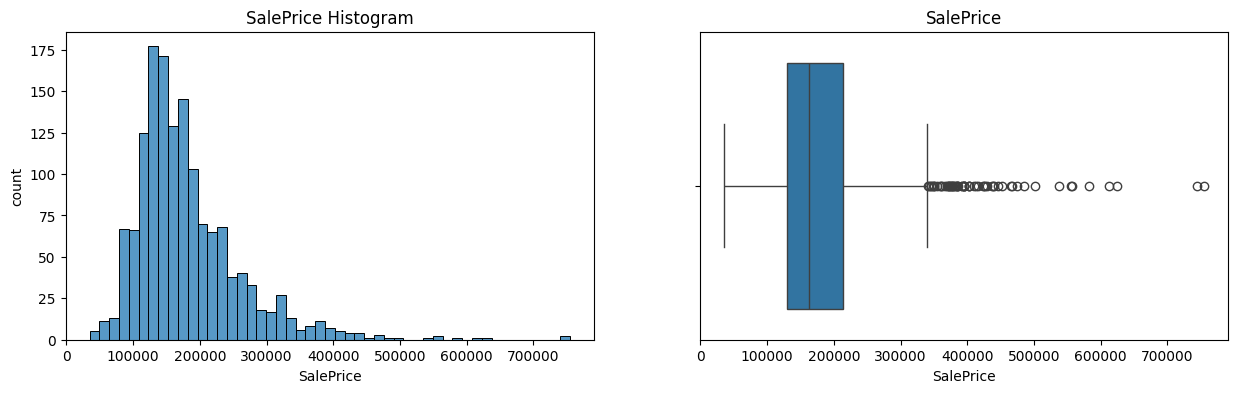

In [11]:
col = 'SalePrice'
print('Skew :', round(df[col].skew(), 2))
plt.figure(figsize=(15, 4))

# Histograms
plt.subplot(1, 2, 1)
sns.histplot(data=df, x=col)
plt.ylabel('count')
plt.title(f'{col} Histogram')

# Boxplot without outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f'{col}')

plt.show()

Significant Skew to the left and several outliers, some extremely outlying

In [12]:
# BoxCox transformation 
# Check skewness before and after
print(f"Original skewness: {df['SalePrice'].skew():.4f}")

transformed_sale_price, lam = stats.boxcox(df['SalePrice'])
print(f"Skew Lambda: {lam:.4f}")
print(f"Transformed skewness: {pd.Series(transformed_sale_price).skew():.4f}")

Original skewness: 1.8829
Skew Lambda: -0.0769
Transformed skewness: -0.0087


Performed a logarithmic transformation

Skew : -0.01


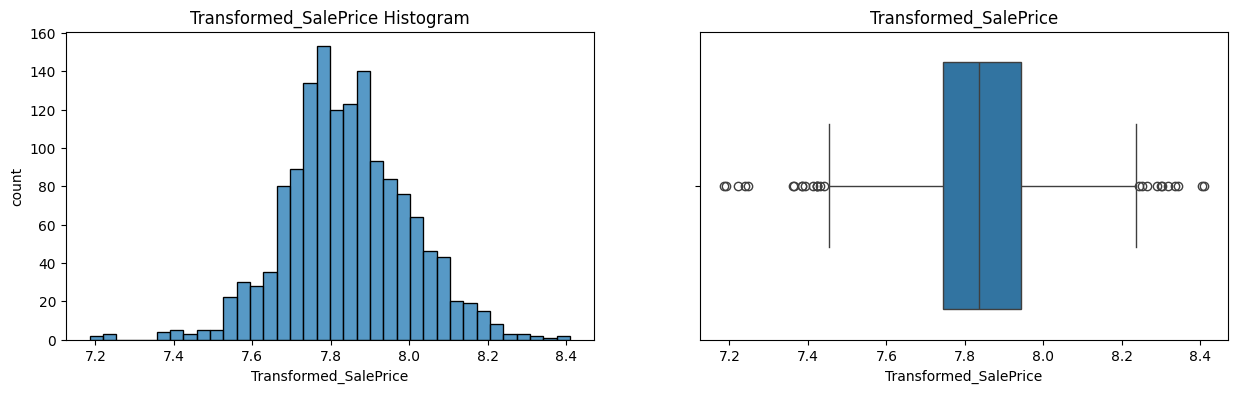

In [13]:
# Response with BoxCox
col = 'Transformed_SalePrice'
viz_df = pd.DataFrame(transformed_sale_price, columns=[col])
print('Skew :', round(viz_df[col].skew(), 2))
plt.figure(figsize=(15, 4))

# Histograms
plt.subplot(1, 2, 1)
sns.histplot(data=viz_df , x=col)
plt.ylabel('count')
plt.title(f'{col} Histogram')

# Boxplot without outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=viz_df[col])
plt.title(f'{col}')

plt.show()

Looks much closer to normally distributed with boxcox logarithmic transformation

# Models

Originally intended to make this a typical kaggle progject where I do a straight forward run through everything. But I encountered an issue where my OLS regression was my top performer, which is unlikely given the n to p ratio. After much troubleshooting, I eventually changed the random seed and saw that I had actually just stumbled into a split in which OLS performed best on. So now Im doing a longer run through with multiple seeds and we can see the change in RMSE across each seed and see the variacne of the models. One main advantage of Regularization is suppose to be that it increases bias for less variance. In a situation where n IS NOT >>p, this is desirable tradeoff to make, as we will see.

## OLS

In [ ]:
def ols_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original):
    ols_model = LinearRegression()
    ols_model.fit(X_train_scaled, y_train)
    y_preds = ols_model.predict(X_test_scaled)
    r_squared_score = ols_model.score(X_test_scaled, y_test)

    # Inverse transform back to dollar scale
    ols_preds_dollars = inv_boxcox(y_preds, lam)
    ols_mse = mean_squared_error(y_test_original, ols_preds_dollars)
    print(f"Mean Squared Error: {ols_mse}")
    ols_rmse = np.sqrt(ols_mse)
    print(f"Root Mean Squared Error: {ols_rmse}") # RMSE will be our basis of comparison across models
    print(f"R-squared score: {r_squared_score}")
    print(f"Intercept: {ols_model.intercept_}")
    
    # Print training RMSE, previously had issues want to make sure that doesnt happen again
    ols_train_preds = inv_boxcox(ols_model.predict(X_train_scaled), lam)
    ols_train_rmse = np.sqrt(mean_squared_error(y_train_original, ols_train_preds))
    print(f"OLS Train RMSE: {ols_train_rmse:.4f}")

    return ols_rmse, ols_preds_dollars

## LassoCv

In [15]:
def lasso_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original):
    # Fit LassoCV
    # Large log space becuase originally wasnt totally capturing the curve
    alphas = np.logspace(-6, 6, 100)
    lcv_model = LassoCV(cv=5, max_iter=10000, alphas=alphas, random_state=42).fit(X_train_scaled, y_train)

    # Extract RMSE Path
    # model.mse_path_ stores MSE for each fold (n_alphas, n_folds)
    # Averaging across folds and take the square root for RMSE
    mean_mse = np.mean(lcv_model.mse_path_, axis=1)
    rmse_path = np.sqrt(mean_mse)
    alphas = lcv_model.alphas_

    # Visualization the RMSE path across different lambdas
    plt.figure(figsize=(10, 6))
    plt.plot(alphas, rmse_path, marker='o', linestyle='-', color='royalblue')
    plt.axvline(lcv_model.alpha_, color='crimson', linestyle='--', label=f'Best Lambda: {lcv_model.alpha_:.4f}')

    plt.xlabel('Lambda (Alpha) - Log Scale')
    plt.ylabel('Mean CV RMSE')
    plt.title('Lasso Cross-Validation: RMSE vs. Lambda')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Optimal Lambda: {lcv_model.alpha_}")
    # Final evaluation on test set using the best lambda
    y_preds = lcv_model.predict(X_test_scaled)
    # Inverse transform back to dollar scale
    lcv_preds_dollars = inv_boxcox(y_preds, lam)
    lasso_rmse = np.sqrt(mean_squared_error(y_test_original, lcv_preds_dollars))
    print(f"Final Test RMSE: {lasso_rmse:.4f}")

    lasso_train_preds = inv_boxcox(lcv_model.predict(X_train_scaled), lam)
    lasso_train_rmse = np.sqrt(mean_squared_error(y_train_original, lasso_train_preds))
    print(f"Lasso Train RMSE: {lasso_train_rmse:.4f}")

    return lasso_rmse, lcv_preds_dollars

## RidgeCV

In [16]:
def ridge_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original):
    # RidgeCV
    # store_cv_values=True is required to access the error path later
    # CV folds not defined becuase when store_cv_results=True for us to make the graph, RidgeCV does LOOCV not folds
    alphas = np.logspace(-2, 6, 100)
    rcv_model = RidgeCV(alphas=alphas, store_cv_results=True).fit(X_train_scaled, y_train)

    # Extract RMSE Path
    # model.cv_values_ contains the error for each sample per alpha
    # Averaging across samples and take the square root for RMSE
    mean_mse = np.mean(rcv_model.cv_results_, axis=0)
    rmse_path = np.sqrt(mean_mse)

    # 4. Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(alphas, rmse_path, marker='o', markersize=4, color='darkorange', label='CV RMSE')
    plt.axvline(rcv_model.alpha_, color='black', linestyle='--', label=f'Best Alpha: {rcv_model.alpha_:.2f}')

    plt.xscale('log')
    plt.xlabel('Alpha (Lambda)')
    plt.ylabel('Mean CV RMSE')
    plt.title('Ridge Regression: RMSE vs. Alpha')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Optimal Alpha: {rcv_model.alpha_:.4f}")
    y_preds = rcv_model.predict(X_test_scaled)
    # Inverse transform back to dollar scale
    rcv_preds_dollars = inv_boxcox(y_preds, lam)
    ridge_rmse = np.sqrt(mean_squared_error(y_test_original, rcv_preds_dollars))
    print(f"Test RMSE at optimal: {ridge_rmse:.4f}")

    ridge_train_preds = inv_boxcox(rcv_model.predict(X_train_scaled), lam)
    ridge_train_rmse = np.sqrt(mean_squared_error(y_train_original, ridge_train_preds))
    print(f"Ridge Train RMSE: {ridge_train_rmse:.4f}")

    return ridge_rmse, rcv_preds_dollars

## PCR

In [17]:
def pcr_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original):
    # PCR
    # Pipline to CV on to perform PCA, then regression
    pcr_pipe = Pipeline([
        ('pca', PCA()),
        ('regression', LinearRegression())
    ])

    # Grid Search for Number of Components
    # Testing from 1 component up to the total number of features
    param_grid = {'pca__n_components': np.arange(1, X.shape[1] + 1)}
    pcr_grid = GridSearchCV(pcr_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
    pcr_grid.fit(X_train_scaled, y_train)

    # Extract RMSE Path
    # GridSearchCV returns negative MSE; we negate and take the square root
    # MSE is negative because GridSearchCV is designed to maximize the score; maximizing a score is standard convention in scikit-learn
    mean_mse = -pcr_grid.cv_results_['mean_test_score']
    rmse_path = np.sqrt(mean_mse)
    components = param_grid['pca__n_components']

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(components, rmse_path, marker='o', markersize=4, color='forestgreen', label='CV RMSE')
    plt.axvline(pcr_grid.best_params_['pca__n_components'], color='red', linestyle='--', 
                label=f"Best Components: {pcr_grid.best_params_['pca__n_components']}")

    plt.xlabel('Number of Principal Components')
    plt.ylabel('Mean CV RMSE')
    plt.title('PCR Cross-Validation: RMSE vs. Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Optimal Components: {pcr_grid.best_params_['pca__n_components']}")
    y_preds = pcr_grid.predict(X_test_scaled)
    # Inverse transform back to dollar scale
    pcr_preds_dollars = inv_boxcox(y_preds, lam)
    pcr_rmse = np.sqrt(mean_squared_error(y_test_original, pcr_preds_dollars))
    print(f"Test RMSE: {pcr_rmse:.4f}")

    return pcr_rmse, pcr_preds_dollars

## PLS

In [18]:
def pls_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original):
    # PLS
    # Pipline to perform CV
    pls_pipe = Pipeline([
        ('pls', PLSRegression())
    ])

    # Grid Search for Number of Components
    # We test from 1 component up to the total number of features
    param_grid = {'pls__n_components': np.arange(1, X.shape[1] + 1)}
    pls_grid = GridSearchCV(pls_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
    pls_grid.fit(X_train_scaled, y_train)

    # Extract RMSE Path
    mean_mse = -pls_grid.cv_results_['mean_test_score']
    rmse_path = np.sqrt(mean_mse)
    components = param_grid['pls__n_components']

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(components, rmse_path, marker='o', markersize=4, color='purple', label='CV RMSE')
    plt.axvline(pls_grid.best_params_['pls__n_components'], color='red', linestyle='--', 
                label=f"Best Components: {pls_grid.best_params_['pls__n_components']}")

    plt.xlabel('Number of PLS Components')
    plt.ylabel('Mean CV RMSE')
    plt.title('PLS Cross-Validation: RMSE vs. Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Optimal Components: {pls_grid.best_params_['pls__n_components']}")
    y_preds = pls_grid.predict(X_test_scaled)
    # Inverse transform back to dollar scale
    pls_preds_dollars = inv_boxcox(y_preds, lam)
    pls_rmse = np.sqrt(mean_squared_error(y_test_original, pls_preds_dollars))
    print(f"Test RMSE: {pls_rmse:.4f}")

    return pls_rmse, pls_preds_dollars

## Run Models


$$$$$ Running seed: 0 $$$$$$
Mean Squared Error: 29521392741.191708
Root Mean Squared Error: 171817.90576418894
R-squared score: 0.7324228078462456
Intercept: 7.841546519712083
OLS Train RMSE: 15668.6416

$$$$$ Running seed: 1 $$$$$$
Mean Squared Error: 617545228.1705623
Root Mean Squared Error: 24850.457303047006
R-squared score: 0.8079898738069153
Intercept: 7.845854735373661
OLS Train RMSE: 17922.1924

$$$$$ Running seed: 2 $$$$$$
Mean Squared Error: 49312930404.188354
Root Mean Squared Error: 222065.1490085474
R-squared score: 0.7173408668518024
Intercept: 7.83925054480549
OLS Train RMSE: 16178.4376

$$$$$ Running seed: 3 $$$$$$
Mean Squared Error: 21032213756.476227
Root Mean Squared Error: 145024.87288901937
R-squared score: 0.784773588948578
Intercept: 7.842756915568974
OLS Train RMSE: 17748.5182

$$$$$ Running seed: 4 $$$$$$
Mean Squared Error: 922384937.5756063
Root Mean Squared Error: 30370.790861872636
R-squared score: 0.6785654146663123
Intercept: 7.84351396967083
OLS Trai

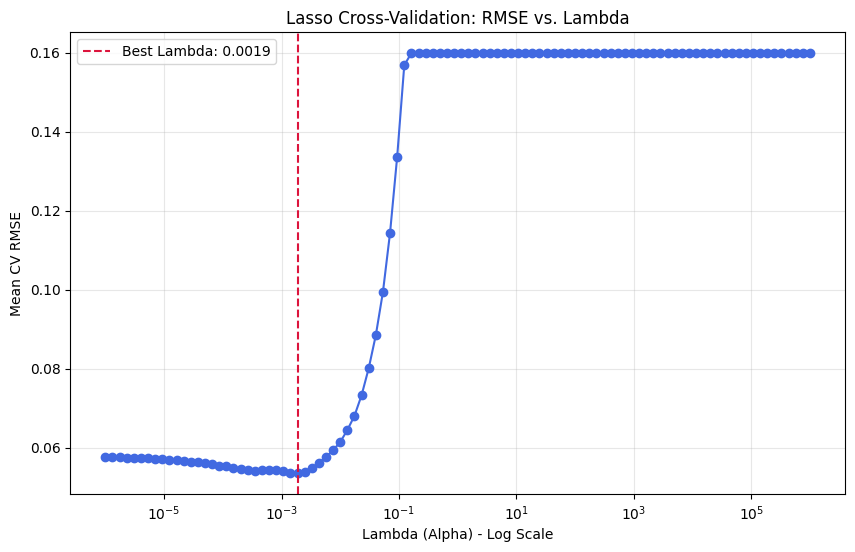

Optimal Lambda: 0.001873817422860385
Final Test RMSE: 170657.4718
Lasso Train RMSE: 19042.8816

$$$$$ Running seed: 1 $$$$$$


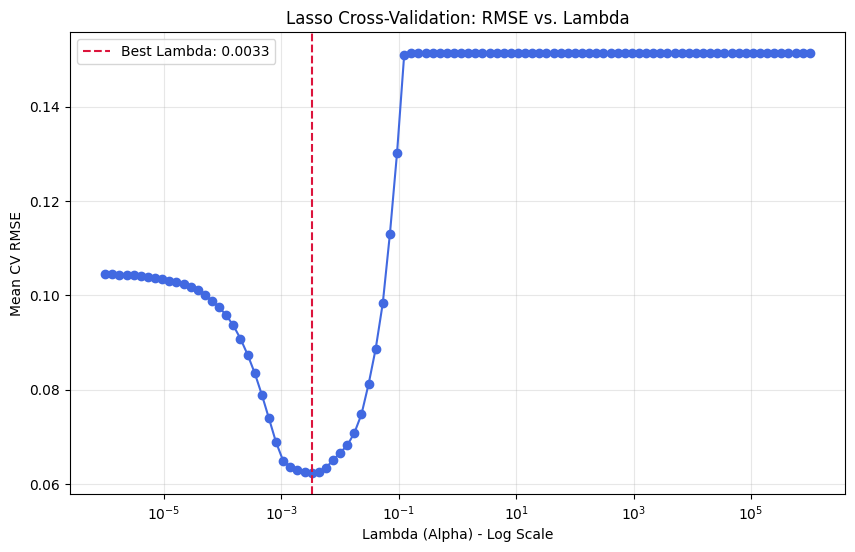

Optimal Lambda: 0.0032745491628777285
Final Test RMSE: 25384.4460
Lasso Train RMSE: 28821.8768

$$$$$ Running seed: 2 $$$$$$


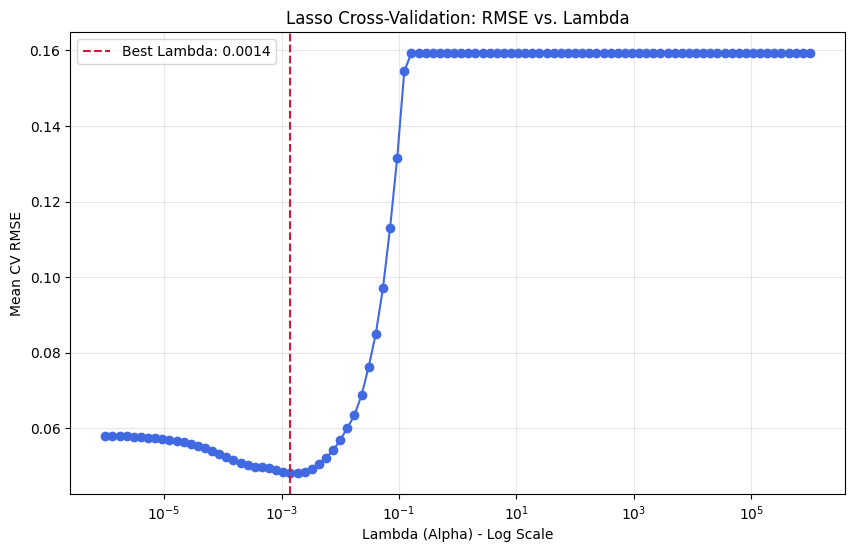

Optimal Lambda: 0.0014174741629268048
Final Test RMSE: 183881.3809
Lasso Train RMSE: 18117.1666

$$$$$ Running seed: 3 $$$$$$


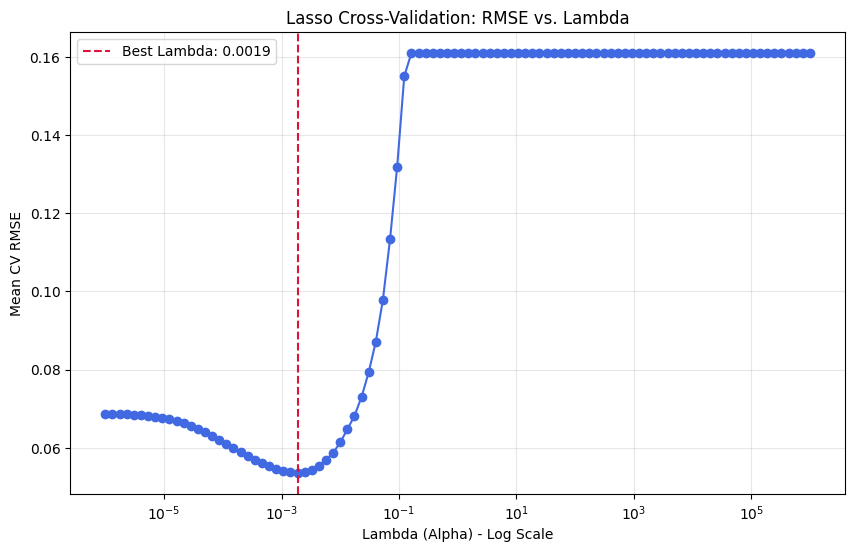

Optimal Lambda: 0.001873817422860385
Final Test RMSE: 132544.8192
Lasso Train RMSE: 21337.6343

$$$$$ Running seed: 4 $$$$$$


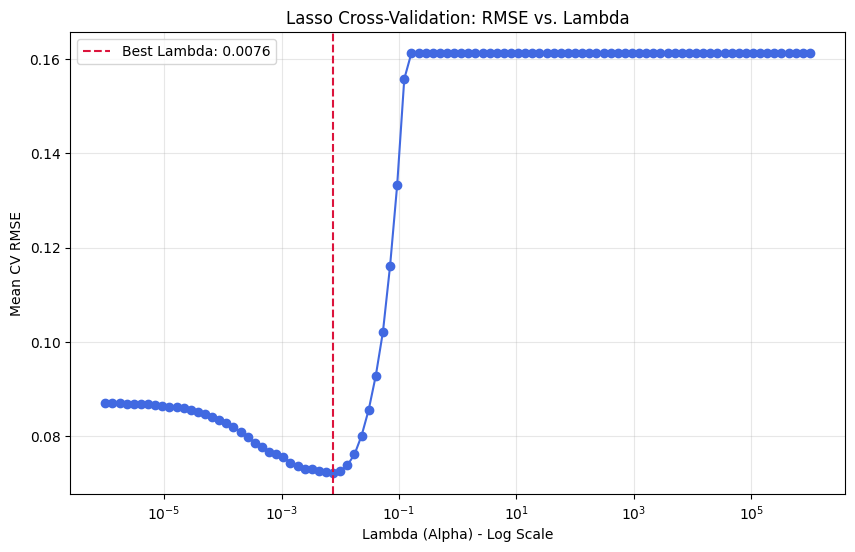

Optimal Lambda: 0.007564633275546291
Final Test RMSE: 26739.5257
Lasso Train RMSE: 34993.3618

$$$$$ Running seed: 5 $$$$$$


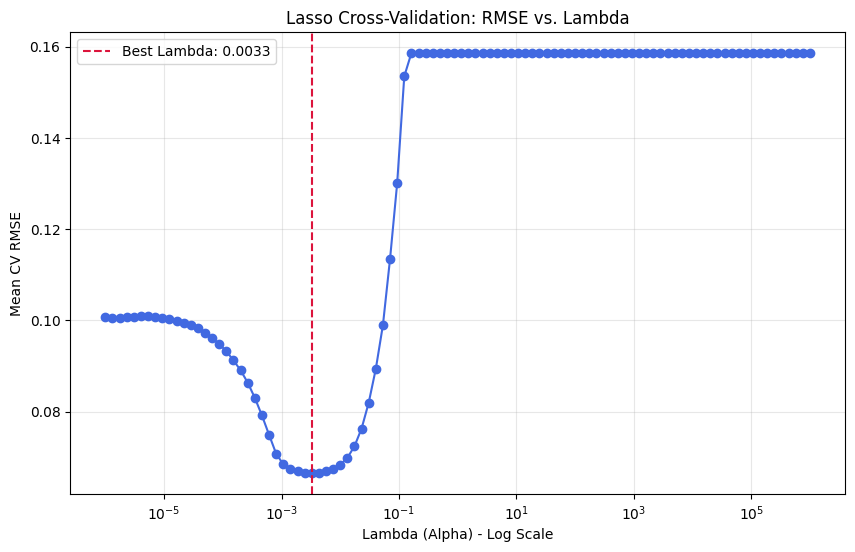

Optimal Lambda: 0.0032745491628777285
Final Test RMSE: 36345.2335
Lasso Train RMSE: 25611.7931

$$$$$ Running seed: 6 $$$$$$


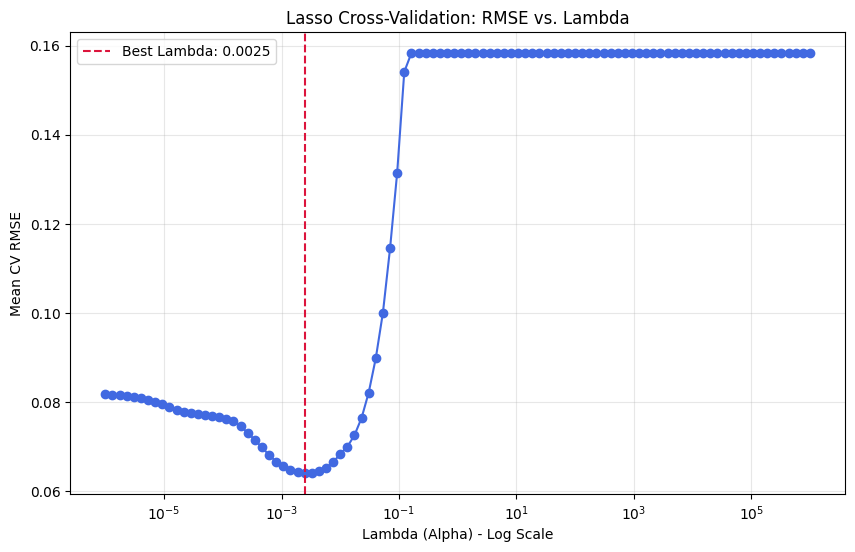

Optimal Lambda: 0.0024770763559917113
Final Test RMSE: 37177.7482
Lasso Train RMSE: 26143.0044

$$$$$ Running seed: 7 $$$$$$


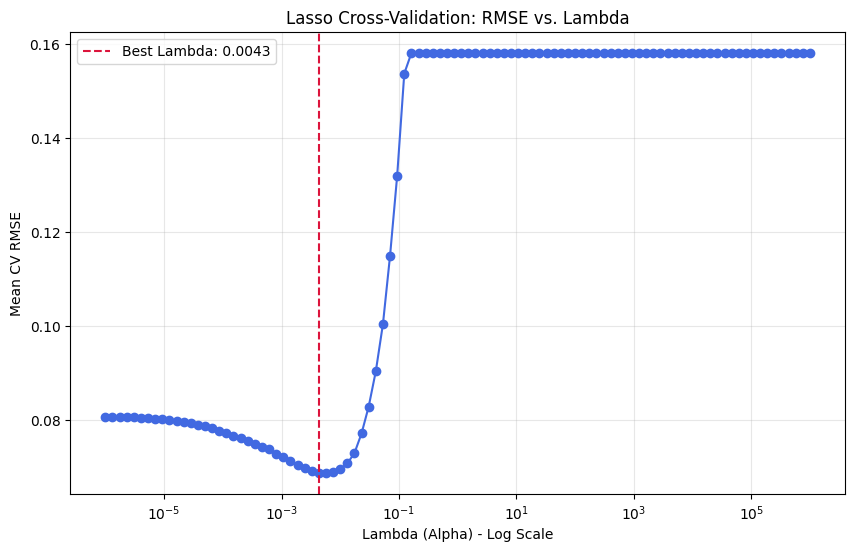

Optimal Lambda: 0.004328761281083062
Final Test RMSE: 29093.7784
Lasso Train RMSE: 28229.0720

$$$$$ Running seed: 8 $$$$$$


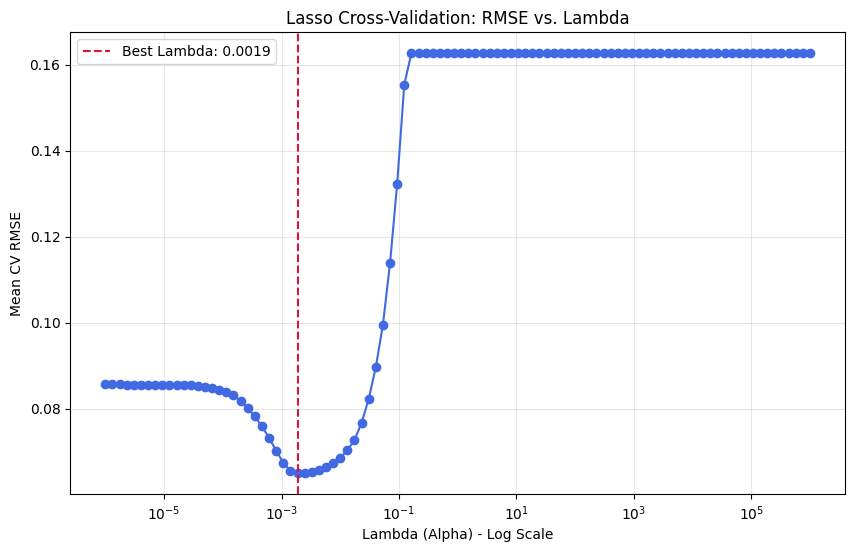

Optimal Lambda: 0.001873817422860385
Final Test RMSE: 35326.9327
Lasso Train RMSE: 25439.6561

$$$$$ Running seed: 9 $$$$$$


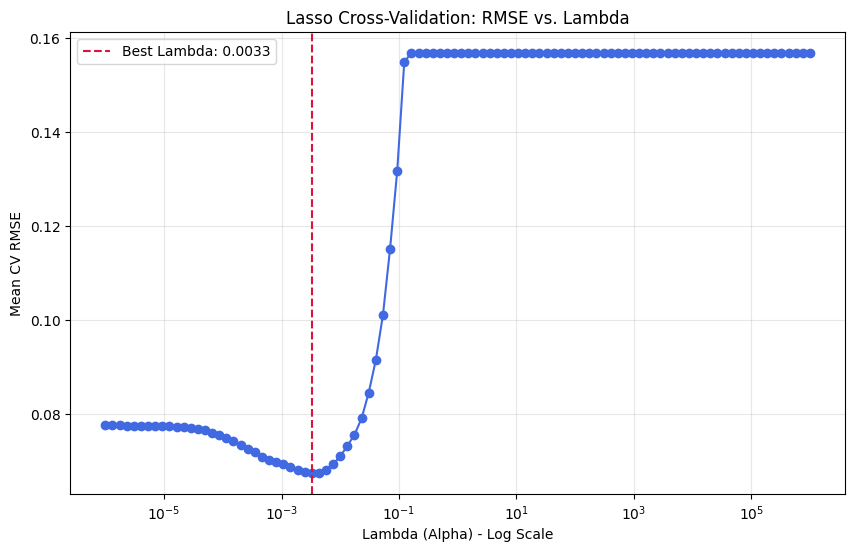

Optimal Lambda: 0.0032745491628777285
Final Test RMSE: 26368.5489
Lasso Train RMSE: 28141.1168

$$$$$ Running seed: 0 $$$$$$


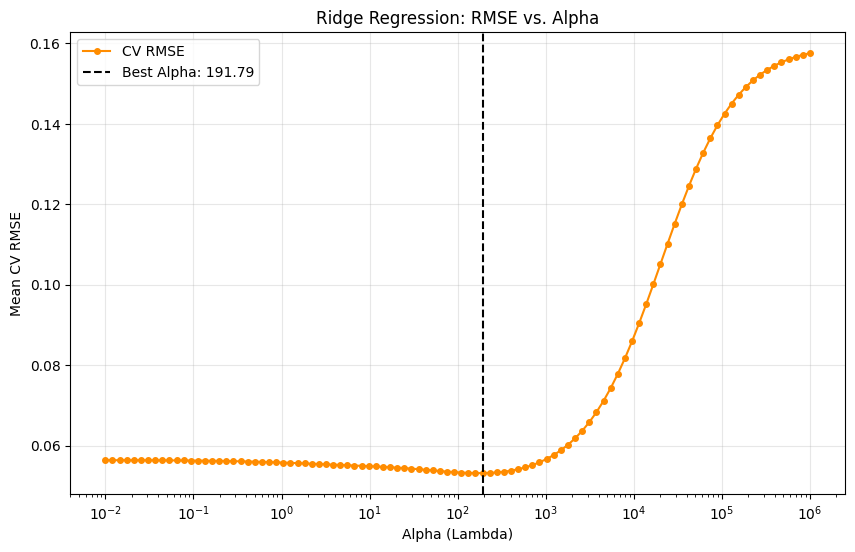

Optimal Alpha: 191.7910
Test RMSE at optimal: 124227.3585
Ridge Train RMSE: 17198.5428

$$$$$ Running seed: 1 $$$$$$


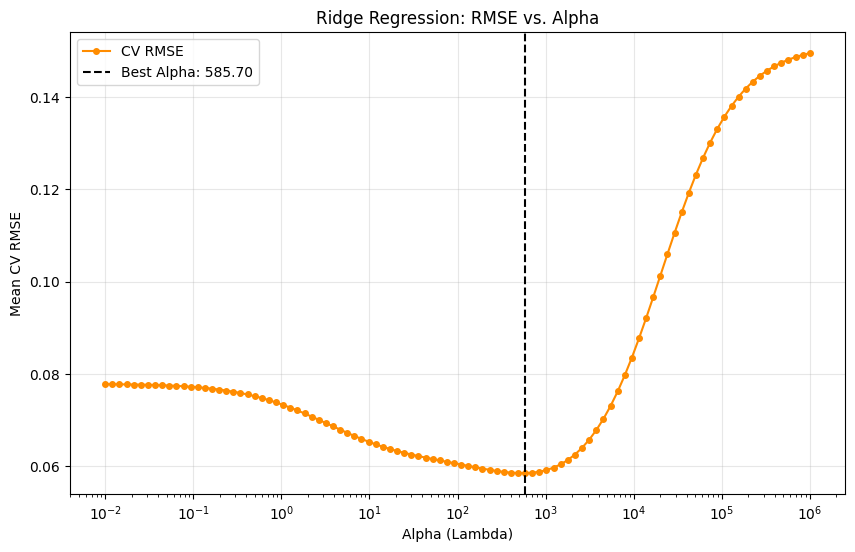

Optimal Alpha: 585.7021
Test RMSE at optimal: 30241.7359
Ridge Train RMSE: 26715.4833

$$$$$ Running seed: 2 $$$$$$


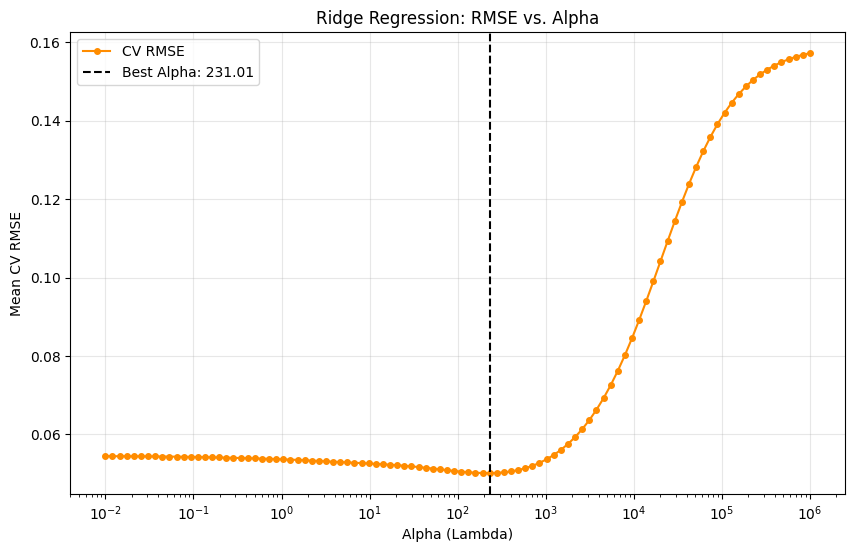

Optimal Alpha: 231.0130
Test RMSE at optimal: 135969.8825
Ridge Train RMSE: 17423.3805

$$$$$ Running seed: 3 $$$$$$


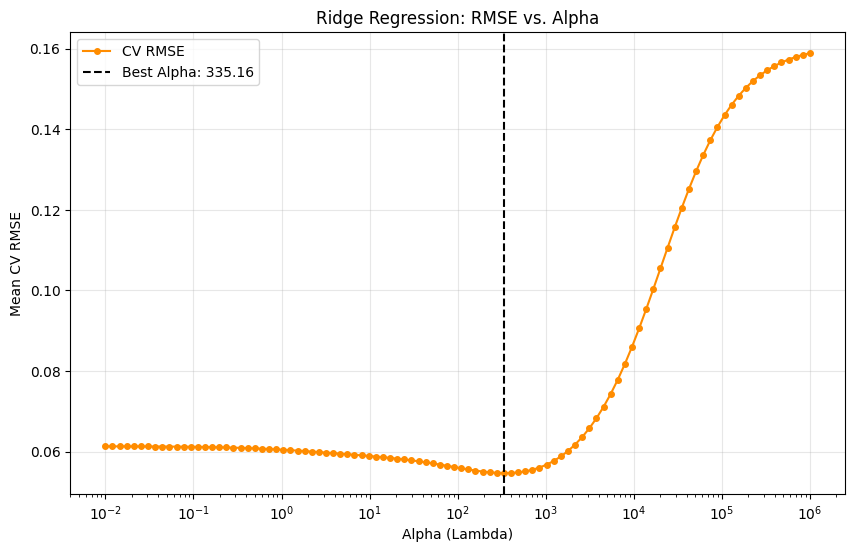

Optimal Alpha: 335.1603
Test RMSE at optimal: 102153.5793
Ridge Train RMSE: 20795.0018

$$$$$ Running seed: 4 $$$$$$


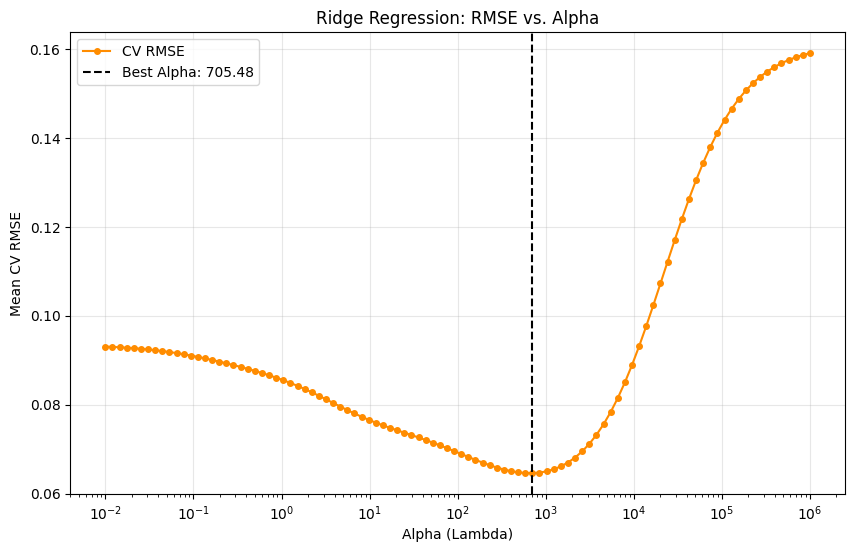

Optimal Alpha: 705.4802
Test RMSE at optimal: 24401.3886
Ridge Train RMSE: 28193.3761

$$$$$ Running seed: 5 $$$$$$


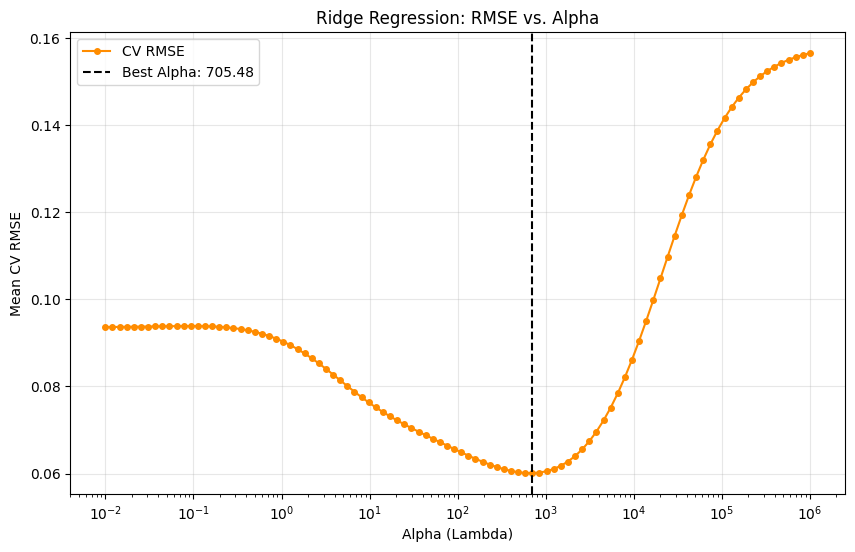

Optimal Alpha: 705.4802
Test RMSE at optimal: 33900.1149
Ridge Train RMSE: 26315.4204

$$$$$ Running seed: 6 $$$$$$


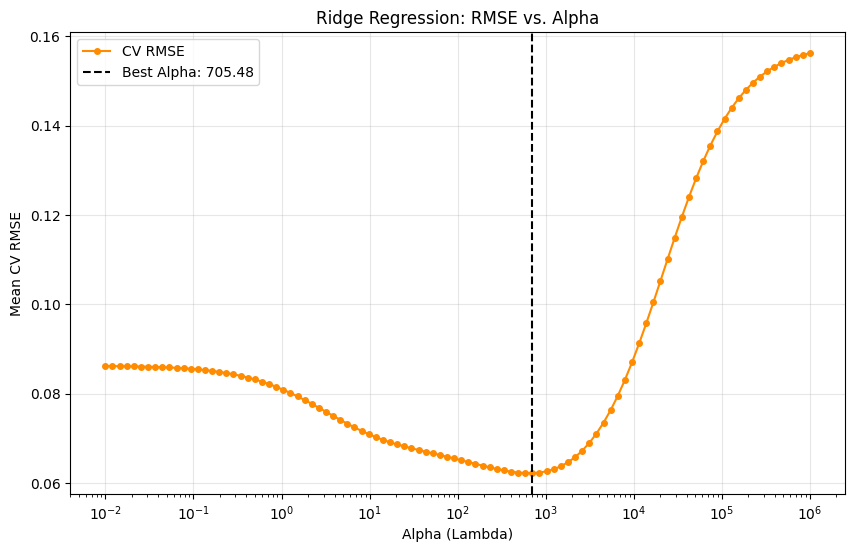

Optimal Alpha: 705.4802
Test RMSE at optimal: 33875.7648
Ridge Train RMSE: 26924.7178

$$$$$ Running seed: 7 $$$$$$


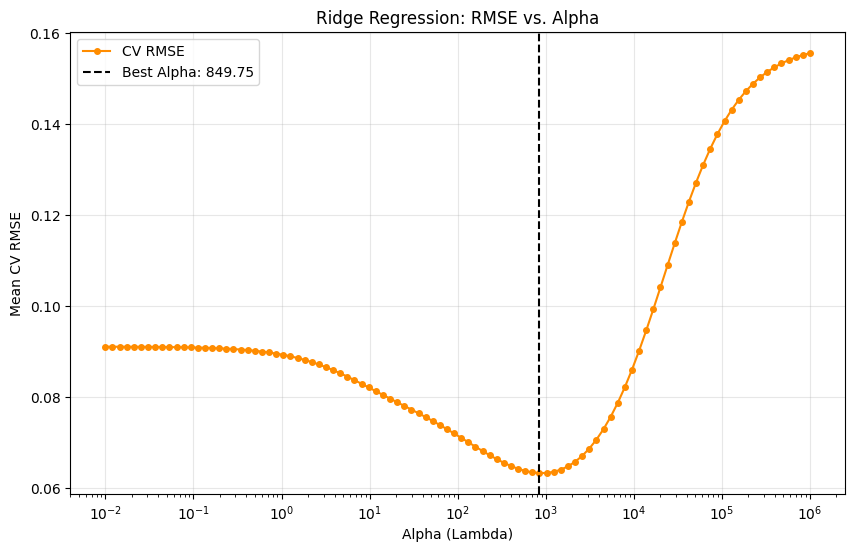

Optimal Alpha: 849.7534
Test RMSE at optimal: 35815.2712
Ridge Train RMSE: 26449.4481

$$$$$ Running seed: 8 $$$$$$


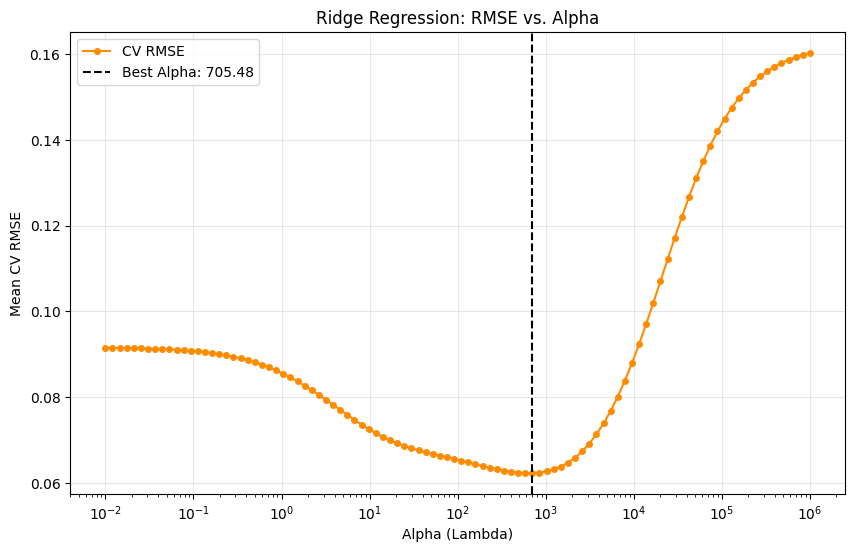

Optimal Alpha: 705.4802
Test RMSE at optimal: 32833.3765
Ridge Train RMSE: 27893.6824

$$$$$ Running seed: 9 $$$$$$


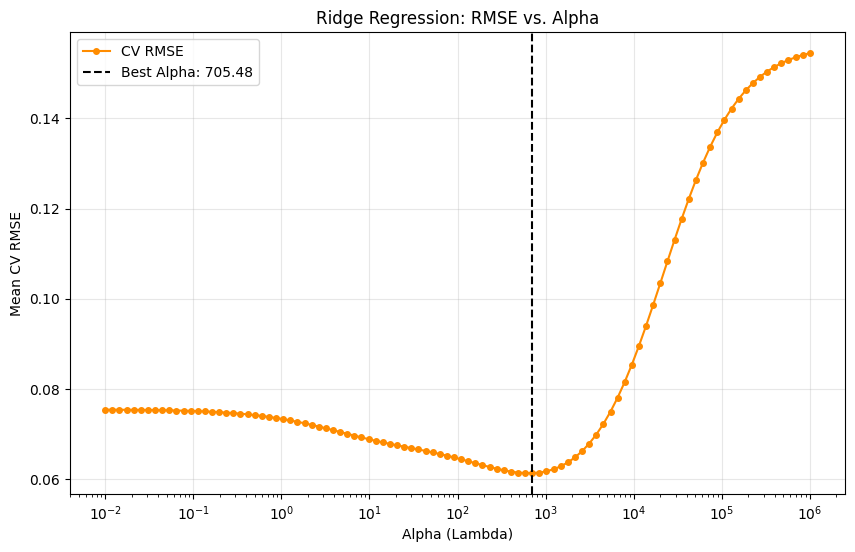

Optimal Alpha: 705.4802
Test RMSE at optimal: 33308.5755
Ridge Train RMSE: 26854.7983

$$$$$ Running seed: 0 $$$$$$

$$$$$ Running seed: 1 $$$$$$

$$$$$ Running seed: 2 $$$$$$

$$$$$ Running seed: 3 $$$$$$

$$$$$ Running seed: 4 $$$$$$


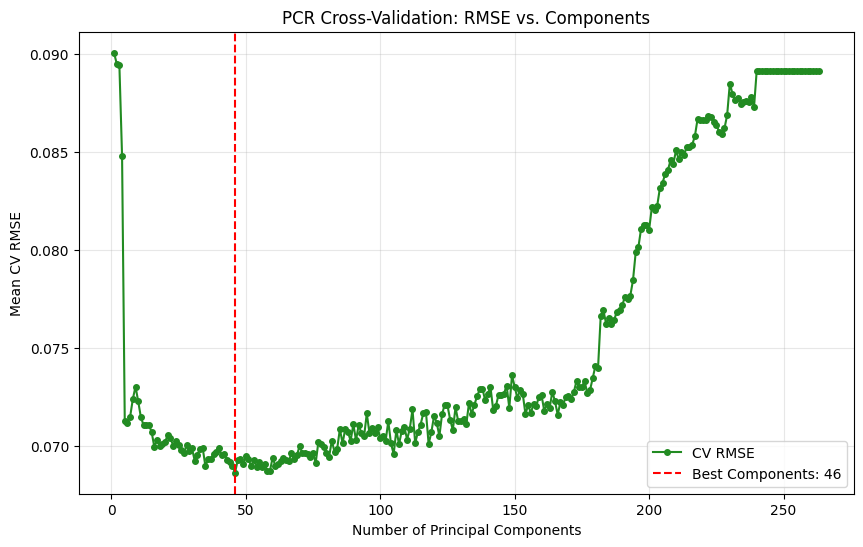

Optimal Components: 46
Test RMSE: 26810.8997

$$$$$ Running seed: 5 $$$$$$

$$$$$ Running seed: 6 $$$$$$

$$$$$ Running seed: 7 $$$$$$

$$$$$ Running seed: 8 $$$$$$

$$$$$ Running seed: 9 $$$$$$

$$$$$ Running seed: 0 $$$$$$

$$$$$ Running seed: 1 $$$$$$

$$$$$ Running seed: 2 $$$$$$

$$$$$ Running seed: 3 $$$$$$

$$$$$ Running seed: 4 $$$$$$


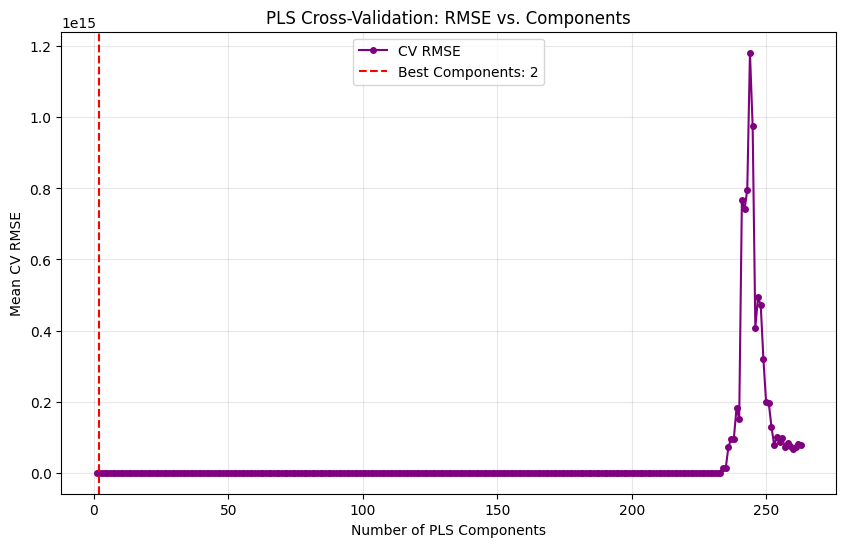

Optimal Components: 2
Test RMSE: 25090.9345

$$$$$ Running seed: 5 $$$$$$

$$$$$ Running seed: 6 $$$$$$

$$$$$ Running seed: 7 $$$$$$

$$$$$ Running seed: 8 $$$$$$

$$$$$ Running seed: 9 $$$$$$


In [ ]:
y_original = df['SalePrice'] # keep original untransformed target for later use in evaluating model performance in dollars
Y = pd.Series(transformed_sale_price)
X = df_encoded.drop('SalePrice', axis=1)

fav_seed = 4 # This is not known ahead of time, but after running and seeing the results, seed 4 appears to be a more stable seed that doesnt cause our models to explode in RMSE like some of the other seeds do
seeds = range(10)
results_rmse = {method: [] for method in ['OLS', 'Lasso', 'Ridge', 'PCR', 'PLS']}
preds = {method: [] for method in ['OLS', 'Lasso', 'Ridge', 'PCR', 'PLS']}

for model in results_rmse.keys():
    for seed in seeds:
        print(f"\n$$$$$ Running seed: {seed} $$$$$$")
        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

        #Second split to make evaluation in dollars
        _, _, y_train_original, y_test_original = train_test_split(X, y_original, test_size=0.3, random_state=seed)

        # Scaling features for regression
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Note that PCR and PLS are ran once. They take awhile unfortuantely. I am choosing seed 4 for their run since I know its a more stable seed
        # As we will see later some of the splits cause big issues for our models and RMSE exploses
        if model == 'OLS':
            ols_rmse, ols_preds = ols_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original)
            results_rmse['OLS'].append(ols_rmse)
            preds['OLS'].append(ols_preds)
        elif model == 'Lasso':
            lasso_rmse, lasso_preds = lasso_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original)
            results_rmse['Lasso'].append(lasso_rmse)
            preds['Lasso'].append(lasso_preds)
        elif model == 'Ridge':
            ridge_rmse, ridge_preds = ridge_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original)
            results_rmse['Ridge'].append(ridge_rmse)
            preds['Ridge'].append(ridge_preds)
        elif model == 'PCR' and seed == fav_seed: # only run PCR for the first seed to save time, since it is very computationally expensive and takes forever to run 10 times
            pcr_rmse, pcr_preds = pcr_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original)
            results_rmse['PCR'].append(pcr_rmse)
            preds['PCR'].append(pcr_preds)
        elif model == 'PLS' and seed == fav_seed: # only run PLS for the first seed to save time, since it is very computationally expensive and takes forever to run 10 times
            pls_rmse, pls_preds = pls_model_func(X_train_scaled, X_test_scaled, y_train, y_test, y_train_original, y_test_original)
            results_rmse['PLS'].append(pls_rmse)
            preds['PLS'].append(pls_preds)
        else:
            results_rmse[model].append(None)
            preds[model].append(None)

        

# Model Summaries

In [21]:
results_df = pd.DataFrame(results_rmse, columns=['OLS', 'Lasso', 'Ridge', 'PCR', 'PLS'])
results_df

,OLS,Lasso,Ridge,PCR,PLS
0,171817.905764,170657.471757,124227.358454,NaN,NaN
1,24850.457303,25384.445999,30241.735909,NaN,NaN
2,222065.149009,183881.380868,135969.882516,NaN,NaN
3,145024.872889,132544.819220,102153.579259,NaN,NaN
4,30370.790862,26739.525676,24401.388602,26810.899673,25090.934483
5,42741.563640,36345.233478,33900.114871,NaN,NaN
6,41671.338276,37177.748151,33875.764836,NaN,NaN
7,35344.987887,29093.778384,35815.271210,NaN,NaN
8,60022.111948,35326.932722,32833.376513,NaN,NaN
9,23474.706517,26368.548885,33308.575502,NaN,NaN


As we can see there exists quite of bit of variance in the models in their RMSE. This obviously isn't ideal but we should keep in mind that this is a fairly sparse dataset with only 1260 obs for 263 features. Variance is likely also increased by the outliers that we saw in the response, SalePrice. The point of this seed looping was to demonstrate just this, how much the location of the split can so fundamentally change the output of our model.

Really wish I could let PCR and PLS run the full seed loop with the others but they just take way too much time.

Although this variation was expected it is still quite extreme and requires some additional checks. In particular Seeds 0 and 2.

In [22]:
for seed in seeds:
    _, _, y_train_orig, y_test_orig = train_test_split(
        X, y_original, test_size=0.3, random_state=seed)
    print(f"Seed {seed}: mean=${y_test_orig.mean():.0f}, max=${y_test_orig.max():.0f}, >$350k: {(y_test_orig > 350000).sum()}")

Seed 0: mean=$181703, max=$745000, >$350k: 18
Seed 1: mean=$179714, max=$745000, >$350k: 21
Seed 2: mean=$183824, max=$755000, >$350k: 17
Seed 3: mean=$179002, max=$501837, >$350k: 16
Seed 4: mean=$178236, max=$501837, >$350k: 14
Seed 5: mean=$179172, max=$755000, >$350k: 7
Seed 6: mean=$180919, max=$755000, >$350k: 15
Seed 7: mean=$183953, max=$755000, >$350k: 20
Seed 8: mean=$183942, max=$538000, >$350k: 15
Seed 9: mean=$185457, max=$755000, >$350k: 17


Cheating a little bit here from circling back. But I know that from residual and QQ plots we know that our models break down in the higher range of prices while being fairly accurate for most of price ranges. So first assumption from this variation in model performance is from a split including a disproportionate number of high outliers. But 0 and 2 do not have disproportionate amount of outliers. Further seed 1 has the most outliers and that run had reasonable RMSE across the models.

In [23]:
for seed in seeds:
    _, _, y_train_orig, y_test_orig = train_test_split(
        X, y_original, test_size=0.3, random_state=seed)
    print(f"Seed {seed}: mean=${y_test_orig.mean():.0f}, max=${y_test_orig.max():.0f}, >$750k: {(y_test_orig > 750000).sum()}")

Seed 0: mean=$181703, max=$745000, >$750k: 0
Seed 1: mean=$179714, max=$745000, >$750k: 0
Seed 2: mean=$183824, max=$755000, >$750k: 1
Seed 3: mean=$179002, max=$501837, >$750k: 0
Seed 4: mean=$178236, max=$501837, >$750k: 0
Seed 5: mean=$179172, max=$755000, >$750k: 1
Seed 6: mean=$180919, max=$755000, >$750k: 1
Seed 7: mean=$183953, max=$755000, >$750k: 1
Seed 8: mean=$183942, max=$538000, >$750k: 0
Seed 9: mean=$185457, max=$755000, >$750k: 1


last check for really extreme values. Doesn't appear to be really extreme values causing the issue, at least that can be isolated to seed 0 and 2.

In [36]:
for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.3, random_state=seed)
    _, _, y_train_original, y_test_original = train_test_split(
        X, y_original, test_size=0.3, random_state=seed)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    print(f"\nSeed {seed} train R²: {model.score(X_train_scaled, y_train):.4f}")
    print(f"Seed {seed} test R²: {model.score(X_test_scaled, y_test):.4f}")


Seed 0 train R²: 0.9530
Seed 0 test R²: 0.7324

Seed 1 train R²: 0.9488
Seed 1 test R²: 0.8080

Seed 2 train R²: 0.9523
Seed 2 test R²: 0.7173

Seed 3 train R²: 0.9445
Seed 3 test R²: 0.7848

Seed 4 train R²: 0.9485
Seed 4 test R²: 0.6786

Seed 5 train R²: 0.9508
Seed 5 test R²: 0.8636

Seed 6 train R²: 0.9478
Seed 6 test R²: 0.7646

Seed 7 train R²: 0.9539
Seed 7 test R²: 0.7818

Seed 8 train R²: 0.9547
Seed 8 test R²: 0.5626

Seed 9 train R²: 0.9405
Seed 9 test R²: 0.7431


Checking for overfitting. Not clear that there is a lot of overfitting in seed 0 and 2 versus the other seeds. In fact, our favorite seed #4 was our most overfit based on its different between training and testing R squared, yet it was one of our best performing.

# Model Analysis

In [25]:
preds_df = pd.DataFrame(preds, columns=['OLS', 'Lasso', 'Ridge', 'PCR', 'PLS'])
preds_df

,OLS,Lasso,Ridge,PCR,PLS
0,"[279109.69699471915, 143508.62260489893, 12607...","[255689.65522177445, 147669.73018295912, 11711...","[281424.63256323163, 140981.999715248, 126639....",None,None
1,"[217549.52843112848, 162083.25413466527, 11417...","[209008.09610791138, 175144.91885409883, 11352...","[218616.17312903563, 179750.2250089812, 113036...",None,None
2,"[297697.50784088083, 160006.94324296882, 37627...","[274507.81646239455, 161881.1857661301, 321336...","[260947.00254980536, 166717.60943136388, 28448...",None,None
3,"[95083.07895809402, 139136.74340484096, 188683...","[99979.98443115177, 140070.26366672615, 190372...","[97984.79501240343, 138726.79476921834, 190589...",None,None
4,"[217169.4460188414, 216739.71463841904, 153030...","[212196.47154747762, 192890.4980910474, 153391...","[218618.6503468452, 207441.86003544496, 149753...","[217688.08605266368, 194989.65941394918, 15097...","[222153.10692402508, 189394.43116216813, 14251..."
5,"[208777.67430624232, 170555.94052002745, 39947...","[219985.82928686234, 188529.7403673988, 99797....","[212082.5109883676, 185325.8171596518, 131639....",None,None
6,"[130226.68376737545, 140733.7515461775, 165756...","[129349.09885961658, 138589.68236866264, 16870...","[123508.45647839368, 131219.31493909887, 16126...",None,None
7,"[156889.64349573993, 193523.16203992456, 18090...","[149544.12364299918, 196317.01946553192, 17573...","[161203.36688585675, 202103.17544946555, 18348...",None,None
8,"[192191.71781706848, 134495.98591161793, 12944...","[166476.83880157574, 133066.94383034678, 13048...","[173042.18004108223, 138424.77614446354, 12861...",None,None
9,"[171086.74052494284, 20219.314614011528, 66364...","[188876.02222281147, 212633.14422194552, 87244...","[174065.15771366094, 188211.2240231936, 67853....",None,None


## Residual Plots

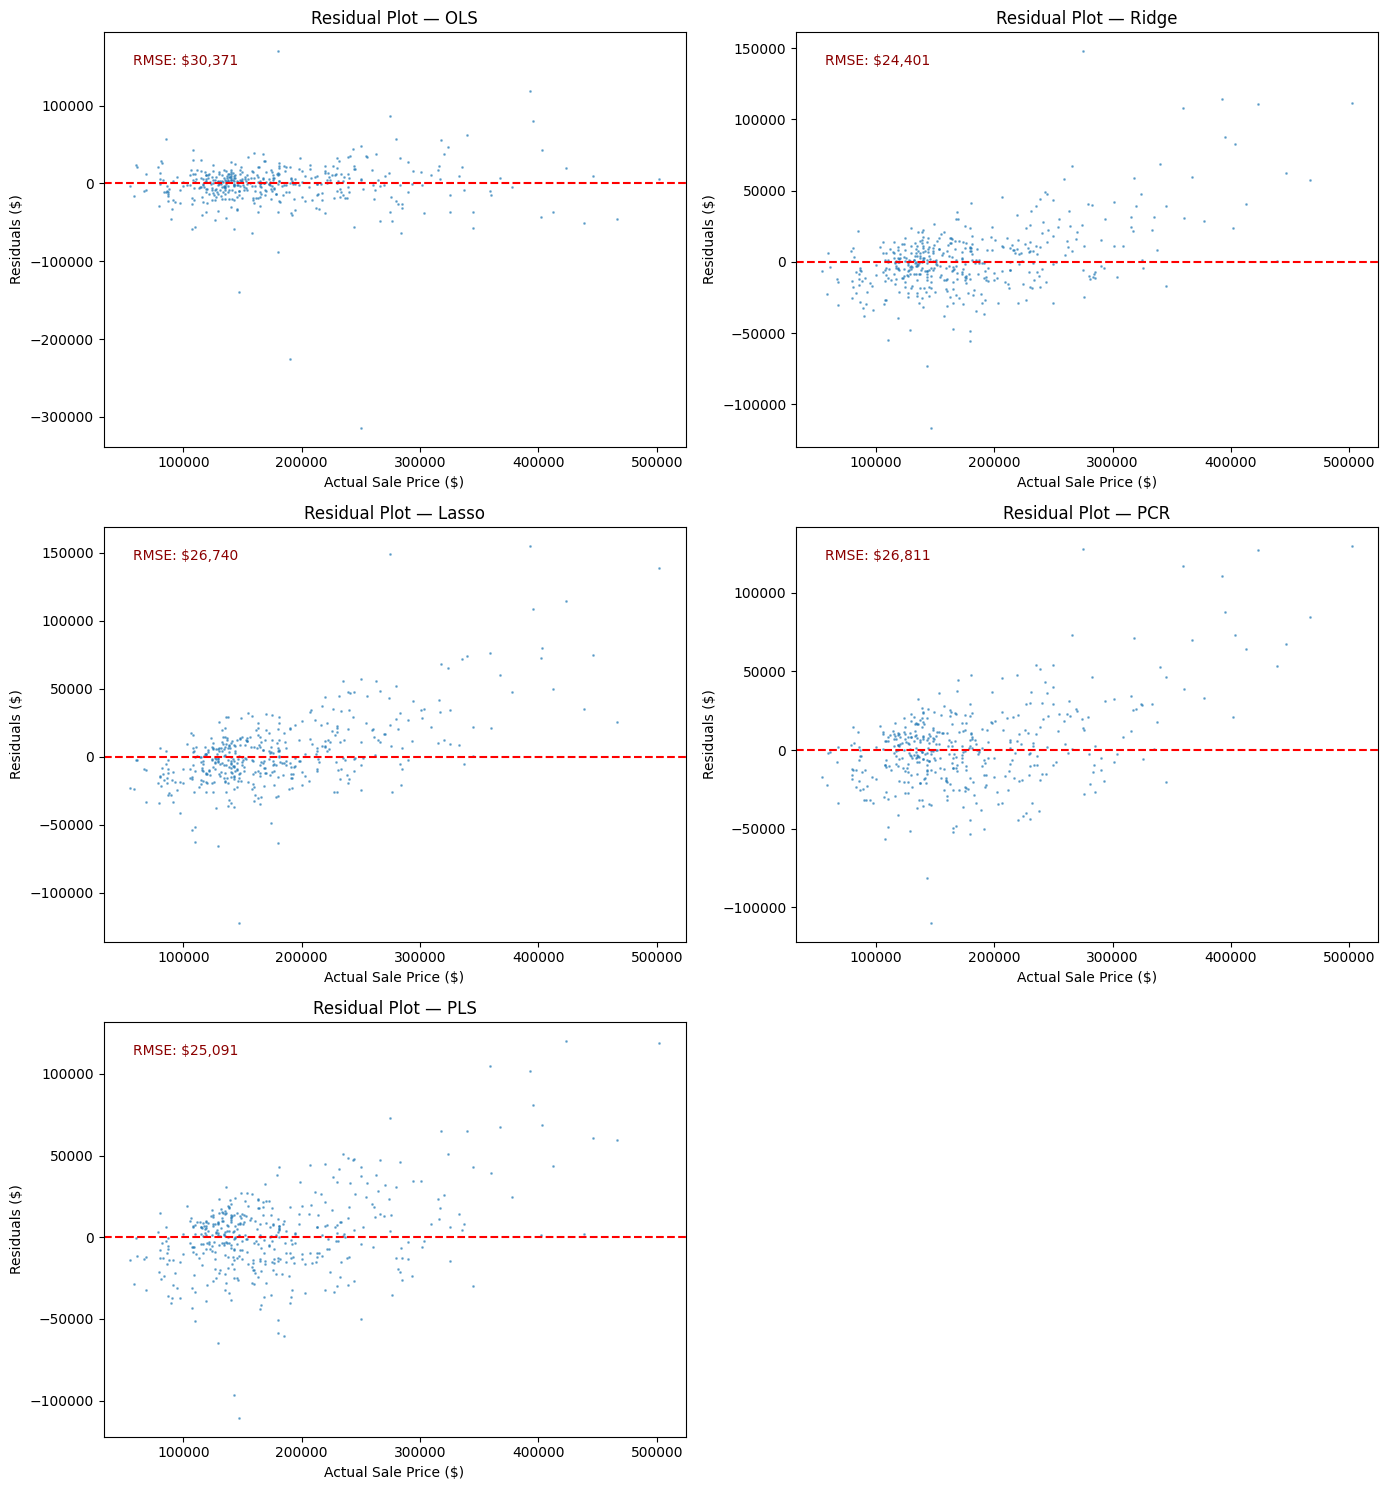

In [ ]:
# Store predictions for each model
models = {
    'OLS': preds_df['OLS'].iloc[fav_seed],
    'Ridge': preds_df['Ridge'].iloc[fav_seed],
    'Lasso': preds_df['Lasso'].iloc[fav_seed],
    'PCR': preds_df['PCR'].iloc[fav_seed],
    'PLS': preds_df['PLS'].iloc[fav_seed]
}

# Get the split specifically for the favorite seed
_, _, y_train_original, y_test_original = train_test_split(X, y_original, test_size=0.3, random_state=fav_seed)

# Plot residuals for all models
plots_per_row = 2
rows = math.ceil(len(models) / plots_per_row)
plt.figure(figsize=(14, rows * 5))

for i, (name, preds) in enumerate(models.items(), 1):
    residuals = y_test_original - preds
    plt.subplot(rows, plots_per_row, i)
    plt.scatter(y_test_original, residuals, alpha=0.5, s=1)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Actual Sale Price ($)')
    plt.ylabel('Residuals ($)')
    plt.title(f'Residual Plot — {name}')

    # RMSE annotation on each plot
    rmse = np.sqrt(mean_squared_error(y_test_original, preds))
    plt.annotate(f'RMSE: ${rmse:,.0f}', 
                xy=(0.05, 0.92), 
                xycoords='axes fraction',
                fontsize=10,
                color='darkred')

plt.tight_layout()
plt.show()

## QQ Plots

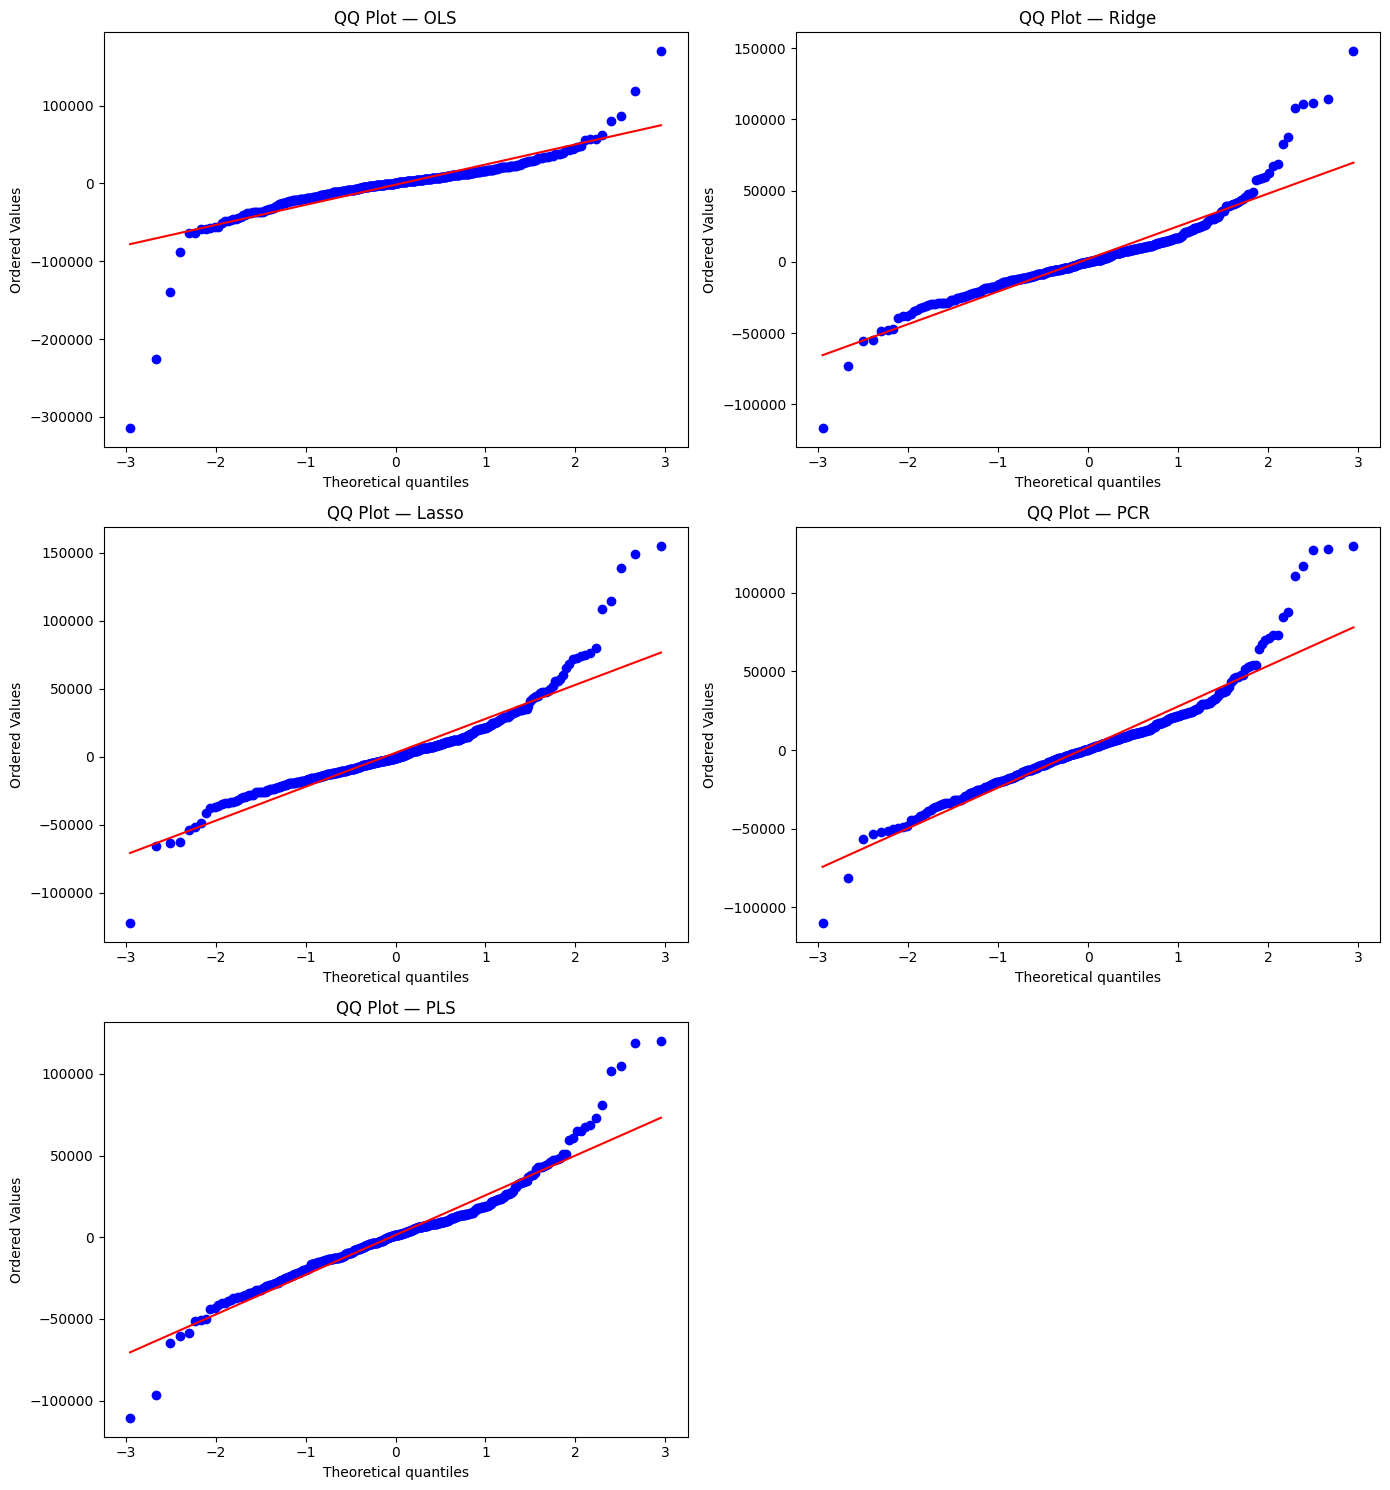

In [33]:
plots_per_row = 2
rows = math.ceil(len(models) / plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(14, rows * 5))
axes = axes.flatten()

for i, (name, preds) in enumerate(models.items()):
    residuals = y_test_original - preds
    stats.probplot(residuals, dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ Plot — {name}')

# Hide empty subplot if odd number of models
if len(models) % plots_per_row != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

From the Residual and QQ plots we can see a clear breakdown in the models at the extremes. Low and high sale prices. Most notably at the high sale prices. Where our models are systematically under valuing those house. Indicating that the low to upper medium priced homes do have have a consistent linear relationships with their features, but the high priced homes do not.

This is likely why we observed so much instability in the models' performance across different seed splits, likely compounded by our boxcox transformation. Where a small error on the transformed training set can be greatly exaggerated after transforming back for evaluation on the testing set.

# Conclusion

In [44]:
print("\nModel RMSE for each seed run:")
print(results_df)
print("\nRMSE Mean:")
print(results_df.mean())
print("\nRMSE Variance:")
print(results_df.std())


Model RMSE for each seed run:
             OLS          Lasso          Ridge           PCR           PLS
0  171817.905764  170657.471757  124227.358454           NaN           NaN
1   24850.457303   25384.445999   30241.735909           NaN           NaN
2  222065.149009  183881.380868  135969.882516           NaN           NaN
3  145024.872889  132544.819220  102153.579259           NaN           NaN
4   30370.790862   26739.525676   24401.388602  26810.899673  25090.934483
5   42741.563640   36345.233478   33900.114871           NaN           NaN
6   41671.338276   37177.748151   33875.764836           NaN           NaN
7   35344.987887   29093.778384   35815.271210           NaN           NaN
8   60022.111948   35326.932722   32833.376513           NaN           NaN
9   23474.706517   26368.548885   33308.575502           NaN           NaN

RMSE Mean:
OLS      79738.388409
Lasso    70351.988514
Ridge    58672.704767
PCR      26810.899673
PLS      25090.934483
dtype: float64

RMSE V

A dataset like Ames Housing Prices is a tough dataset becuase it has a reletively small ratio of observations (1,460) to features (263 once encoded). Interestingly, when first doing this project I stumbled into finding that OLS was my top performer, but later discovered this was an issue of the seed split in training and testing data. Which sparked an idea to transform this project into a demonstration of how regularization can help improve predictive accuracy from the bias-variance tradeoff; maintaing solid results across different data sets.

Unforutnatley due to how long PCR and PLS take to run, they were both only run once when testing across the seed splits. 

Ridge regression was our clear winner between Lasso, OLS, and itself. 

Ridge regression achieved the lowest mean RMSE ($58,673) and lowest standard deviation ($43,726), outperforming OLS and Lasso despite both occasionally winning on individual splits. The key rounds for Ridge's superior performance were our "bad" seeds run, 0 and 2. Where all three model underperformed, but Ridge kept its underperformance modest in comparison. This empirically demonstrates regularization's core advantage: not just lower average error, but dramatically more reliable generalization across different sets of data. 